Generated availability matrix using SCIP tool. For different carbon budget, fetch the final best accuracy

# Display Test Accuracy

In [1]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat

from matplotlib import pyplot as plt
from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

In [2]:
NON_IID, IID = "0.1", "100000"

In [3]:
def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test) 

                                        if os.path.exists(event_dir):
                                            # print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, "availability": av,
                                                "alpha": a, "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "test_loss": "Test/Loss",
                                                "train_accuracy": "Train/Metric",
                                                "train_loss": "Train/Loss",
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

In [4]:
main_folder = 'model_quality'

In [5]:
def modify_data(_df):
    tmp = _df.groupby(['algorithm', 'availability','lr', 'alpha']).test_accuracy.apply(np.vstack).to_frame().reset_index()
    tmp['mean_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.mean(axis=0))
    tmp['var_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.var(axis=0))
    tmp['std_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.std(axis=0))
    tmp['final_mean_acc'] = tmp['mean_test_acc'].apply(lambda x : x[-1])
    tmp['final_var_acc'] = tmp['var_test_acc'].apply(lambda x : x[-1])
    tmp['final_std_acc'] = tmp['std_test_acc'].apply(lambda x : x[-1])
    tmp['min_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.min(axis=0))
    tmp['max_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.max(axis=0))
    return tmp

def get_plt(tmp, data_type=NON_IID, ft=True):
    # Filter and process data for FedAvg
    fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
    fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)

    # Filter and process data for FedVarp
    fedvarp = tmp.loc[(tmp['algorithm'] == 'fedvarp') & (tmp['alpha'] == data_type)]
    fedvarp['avail_mat'] = fedvarp['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)

    # Plot
    plt.figure(figsize=(10, 8))

    # Plot for FedAvg with lr differentiation
    for lr_value in fed_avg['lr'].unique():
        subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
        plt.plot(
            subset['avail_mat'], subset['final_mean_acc'], 
            marker='o', label=f'FedAvg (lr={lr_value})'
        )
        plt.fill_between(
            subset['avail_mat'], 
            subset['final_mean_acc'] - subset['final_var_acc'], 
            subset['final_mean_acc'] + subset['final_var_acc'], 
            alpha=0.2
        )

    # Plot for FedVarp with lr differentiation
    for lr_value in fedvarp['lr'].unique():
        subset = fedvarp[fedvarp['lr'] == lr_value].sort_values('avail_mat')
        plt.plot(
            subset['avail_mat'], subset['final_mean_acc'], 
            marker='o', linestyle='--', label=f'FedVarp (lr={lr_value})'
        )
        plt.fill_between(
            subset['avail_mat'], 
            subset['final_mean_acc'] - subset['final_var_acc'], 
            subset['final_mean_acc'] + subset['final_var_acc'], 
            alpha=0.2
        )
        

    # Add labels and legend
    plt.xlabel('Carbon Budget', fontsize=12)
    plt.ylabel('Final Test Accuracy (with Variance)', fontsize=12)
    plt.title(f'{data_type} case {"with" if ft else "no"} ft', fontsize=14)
    plt.grid(visible=True, which='both')
    plt.minorticks_on()  # Enable minor ticks for finer granularity
    plt.ylim(0,1)
    plt.legend()
    plt.show()



Final Accuracy: 0.9685999751091003


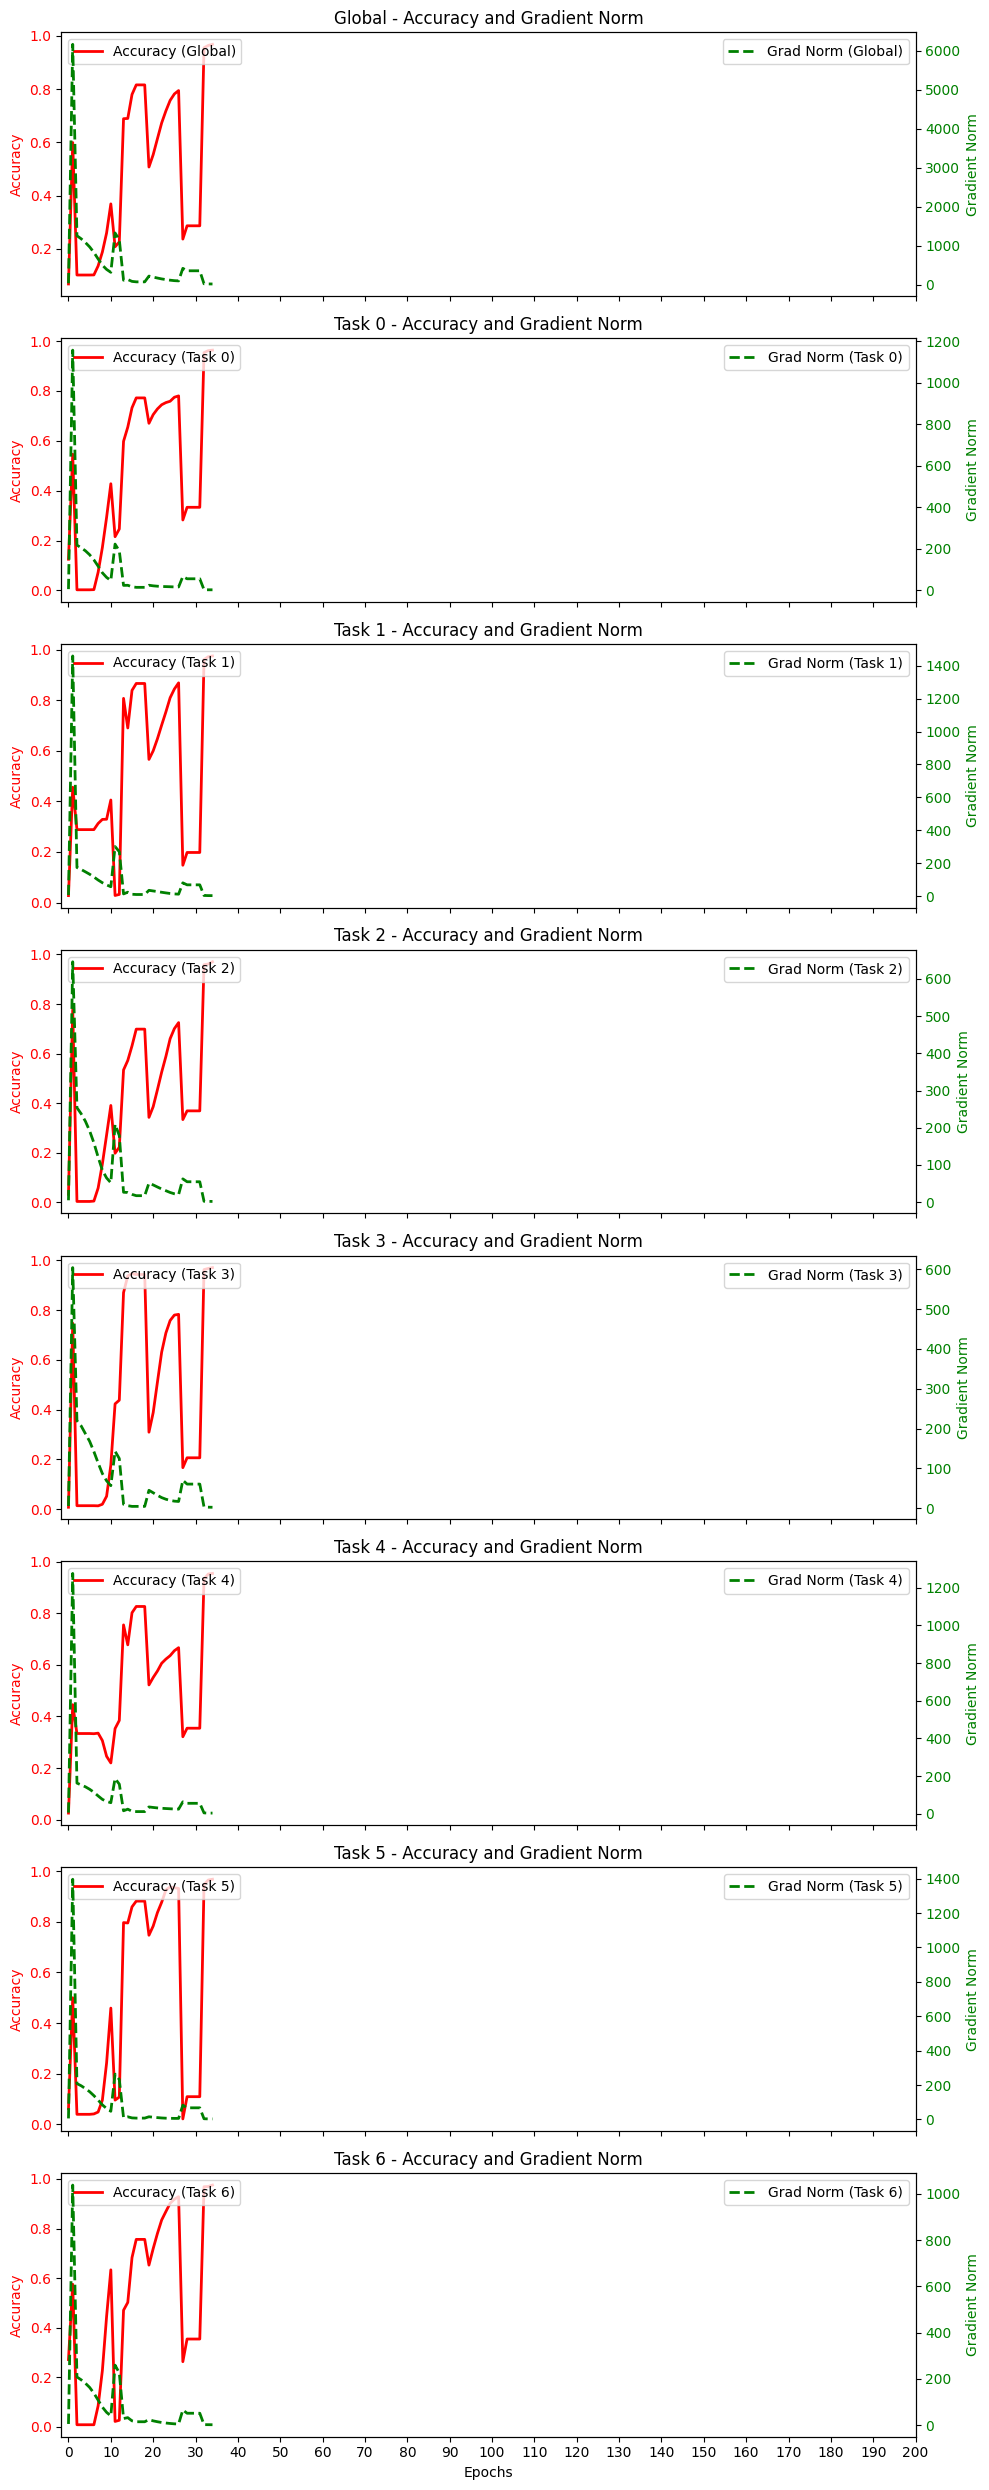

In [74]:
alp = "11"
sl_v = "34"
seed = "84"
lr="5e-2"
ft = "3"
_, test_acc_global = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/global", tag="Test/Metric")
_, test_global_grad = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/global", tag="Test/GradNorm")
_, test_acc_1 = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_0", tag="Test/Metric")
_, test_1_grad = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_0", tag="Test/GradNorm")
_, test_acc_2 = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_1", tag="Test/Metric")
_, test_2_grad = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_1", tag="Test/GradNorm")
_, test_acc_3 = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_2", tag="Test/Metric")
_, test_3_grad = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_2", tag="Test/GradNorm")
_, test_acc_4 = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_3", tag="Test/Metric")
_, test_4_grad = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_3", tag="Test/GradNorm")
_, test_acc_5 = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_4", tag="Test/Metric")
_, test_5_grad = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_4", tag="Test/GradNorm")
_, test_acc_6 = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_5", tag="Test/Metric")
_, test_6_grad = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_5", tag="Test/GradNorm")
_, test_acc_7 = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_6", tag="Test/Metric")
_, test_7_grad = parse_tf_events_file(f"../logs/mnist_debug/alphaF50-{sl_v}sl-{alp}cb-{ft}ft/biased_2/fedavg/alpha_0.5/lr_{lr}/seed_{seed}/train/task_6", tag="Test/GradNorm")

# Create a figure with 8 subplots (one for each task, including the global one)
fig, axs = plt.subplots(8, 1, figsize=(10, 25), sharex=True)

# Define the data and labels for each subplot
tasks = [
    ("Global", test_acc_global, test_global_grad),
    ("Task 0", test_acc_1, test_1_grad),
    ("Task 1", test_acc_2, test_2_grad),
    ("Task 2", test_acc_3, test_3_grad),
    ("Task 3", test_acc_4, test_4_grad),
    ("Task 4", test_acc_5, test_5_grad),
    ("Task 5", test_acc_6, test_6_grad),
    ("Task 6", test_acc_7, test_7_grad),
]
print("Final Accuracy:", test_acc_global[-1])
x_values = np.arange(201)  # This will create an array from 0 to 100 (101 data points)
x_ticks = np.arange(0, 201, 10)  # This will create ticks every 5 epochs (0, 5, 10, ..., 100)
# Loop through each subplot and plot the data
for i, (task_name, acc_data, grad_data) in enumerate(tasks):
    ax1 = axs[i]  # Select the subplot

    # Plot accuracy on the left y-axis
    ax1.plot(acc_data, 'r', label=f'Accuracy ({task_name})', linewidth=2)
    ax1.set_ylabel('Accuracy', color='r')
    ax1.tick_params(axis='y', labelcolor='r')

    # Create the second y-axis for gradient norm
    ax2 = ax1.twinx()
    ax2.plot(grad_data, 'g', label=f'Grad Norm ({task_name})', linestyle='--', linewidth=2)
    ax2.set_ylabel('Gradient Norm', color='g')
    ax2.tick_params(axis='y', labelcolor='g')

    # Set title for each subplot
    ax1.set_title(f"{task_name} - Accuracy and Gradient Norm")

    # Set the x-ticks and labels on every subplot
    ax2.set_xticks(x_ticks)
    ax2.set_xticklabels(x_ticks)

    # Optional: Add legend to each subplot
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

# Set x-axis label for the bottom subplot
axs[-1].set_xlabel('Epochs')

# Adjust layout to prevent overlap
fig.tight_layout()

# Show the plot
plt.show()

# With full data

/tmp/ipykernel_5510/1426562654.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)
/tmp/ipykernel_5510/1426562654.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fedvarp['avail_mat'] = fedvarp['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)


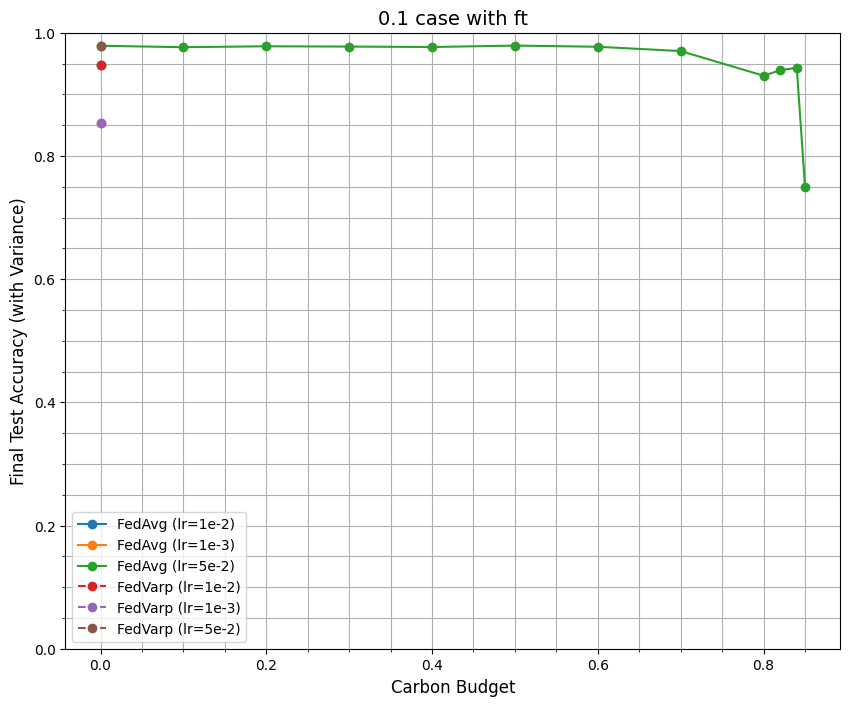

/tmp/ipykernel_5510/1426562654.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)
/tmp/ipykernel_5510/1426562654.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fedvarp['avail_mat'] = fedvarp['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)


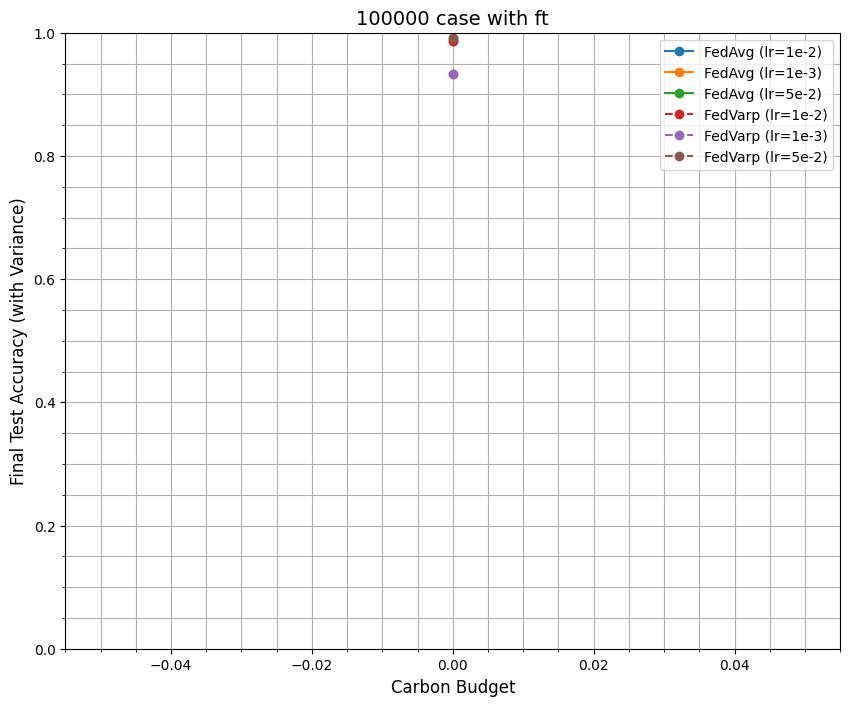

/tmp/ipykernel_5510/1426562654.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)
/tmp/ipykernel_5510/1426562654.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fedvarp['avail_mat'] = fedvarp['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)


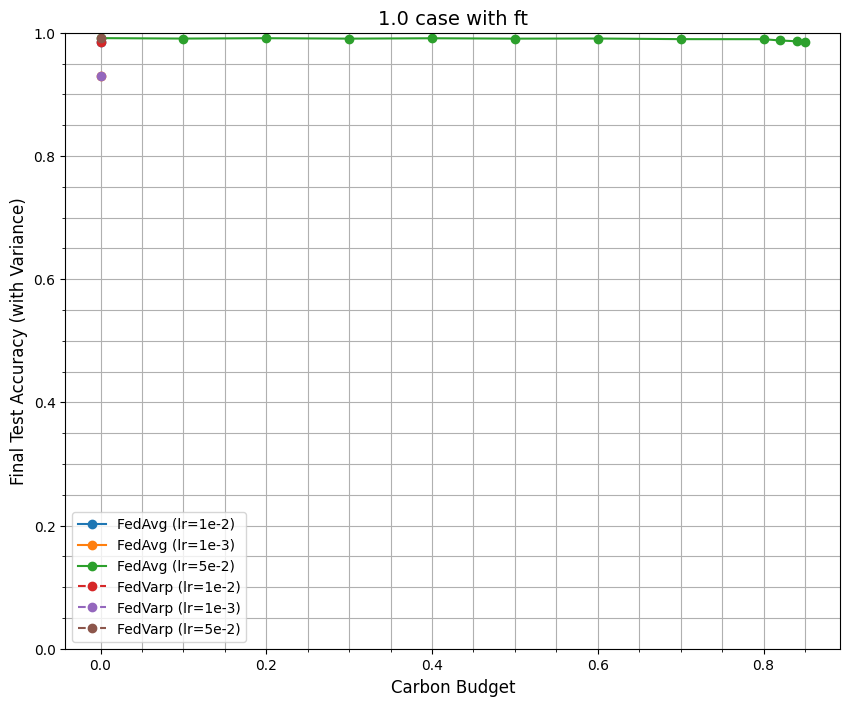

In [7]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    seeds=["42","78","84"],
    algorithms=["fedavg", "fedvarp"],
    events=["global"],
    lr_list=["5e-2", "1e-2", "1e-3"],
    alphas=[NON_IID, IID, "1.0"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF-0.0cb-10ft-mod alphaF-0.1cb-10ft2 alphaF-0.2cb-10ft2 alphaF-0.3cb-10ft2 alphaF-0.4cb-10ft2 alphaF-0.5cb-10ft2 alphaF-0.6cb-10ft2 alphaF-0.7cb-10ft2 alphaF-0.8cb-10ft2 alphaF-0.82cb-10ft2 alphaF-0.84cb-10ft2 alphaF-0.85cb-10ft2".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)
get_plt(modify_data(_df=results_df), NON_IID, ft=True)
get_plt(modify_data(_df=results_df), IID, ft=True)
get_plt(modify_data(_df=results_df), "1.0", ft=True)

In [8]:
tmp = modify_data(results_df)
data_type = NON_IID
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

# Load baseline availability matrix and calculate list_0
_tmp = pd.read_csv(
    "../building_availability_matrices/availability_matrices/av-mat-5_av-mat-analysis/2022-01-01_00/av-mat_alphaF-0.0cb-10ft-mod.csv", 
    index_col=0
)
list_0 = [1 - _tmp[_tmp.columns[:i]].sum().sum() / _tmp.sum().sum() for i in [15, 16, 18, 20, 30, 40, 50, 60, 70, 80, 90, 100]]

# Plotting
plt.figure(figsize=(10, 8))

# Define a colormap for consistent colors
colormap = plt.cm.tab10  # Or another colormap of your choice
unique_lr_values = fed_avg['lr'].unique()
color_map = {lr: colormap(i / len(unique_lr_values)) for i, lr in enumerate(unique_lr_values)}

# Plot FedAvg and Baseline for each learning rate
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Extract baseline data (dummy placeholder logic; replace with actual calculation)
    _tmp1 = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0].take([15,16,18, 20, 30, 40, 50, 60, 70, 80, 90, 100])
    
    # Plot FedAvg (solid line)
    plt.plot(
        subset['avail_mat'], subset['final_mean_acc'], 
        marker='o', label=f'FedAvg (lr={lr_value})', 
        color=color_map[lr_value], linestyle='-'
    )
    plt.fill_between(
        subset['avail_mat'], 
        subset['final_mean_acc'] - subset['final_var_acc'], 
        subset['final_mean_acc'] + subset['final_var_acc'], 
        alpha=0.2, color=color_map[lr_value]
    )
    
    # Plot Baseline (dashed line)
    plt.plot(
        list_0, _tmp1, 
        marker='o', label=f'Baseline (lr={lr_value})', 
        color=color_map[lr_value], linestyle='--'
    )

# Add labels, legend, and other plot details
plt.xlabel('Carbon Budget', fontsize=12)
plt.ylabel('Final Test Accuracy (with Variance)', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()  # Enable minor ticks for finer granularity
plt.legend()
plt.show()

/tmp/ipykernel_5510/2330753569.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)


FileNotFoundError: [Errno 2] No such file or directory: '../building_availability_matrices/availability_matrices/av-mat-5_av-mat-analysis/2022-01-01_00/av-mat_alphaF-0.0cb-10ft-mod.csv'

/tmp/ipykernel_35217/4247042691.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)


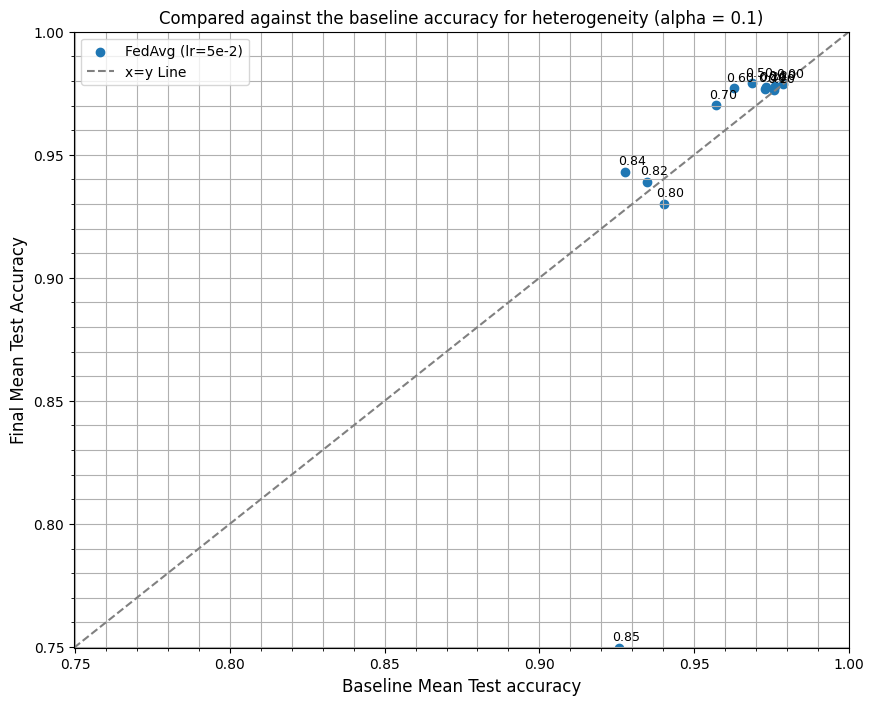

In [ ]:
tmp = modify_data(results_df)
data_type = NON_IID
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

plt.figure(figsize=(10, 8))

unique_lr_values = ["5e-2"] #fed_avg['lr'].unique()
x_min= 1.0
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Corrected line extraction
    baseline_tmp = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0][[15,16,18, 20, 30, 40, 50, 60, 70, 80, 90, 100]][::-1]
    
    plt.scatter(
        baseline_tmp,
        subset['final_mean_acc'],
        marker='o', 
        label=f'FedAvg (lr={lr_value})'
    )
    
    for i in range(len(baseline_tmp)):
        plt.annotate(
            f'{subset["avail_mat"].values[i]:.2f}', 
            (baseline_tmp[i], subset['final_mean_acc'].values[i]), 
            xytext=(5, 5), 
            textcoords="offset points", 
            ha='center', 
            fontsize=9
        )
    
    # Add x=y line
    x_min = min(min(baseline_tmp), subset['final_mean_acc'].min(),x_min)


plt.plot([x_min, 1.0], [x_min, 1.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 1.0)
plt.ylim(x_min, 1.0)
plt.title(f"Compared against the baseline accuracy for heterogeneity (alpha = {data_type})")
plt.legend()
plt.show()

/tmp/ipykernel_35217/1243487959.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)


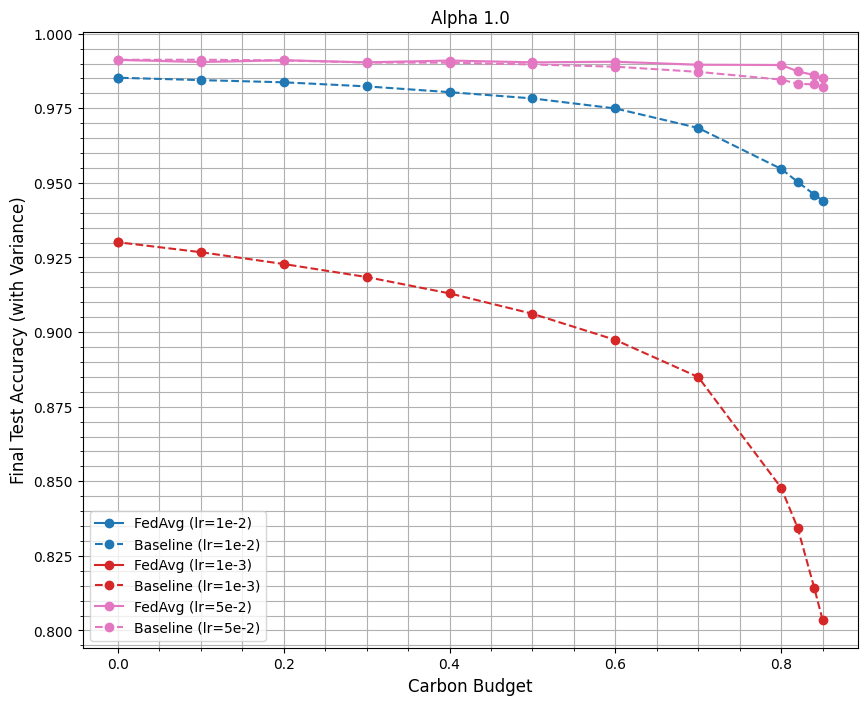

In [ ]:
tmp = modify_data(results_df)
data_type = "1.0"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

# Load baseline availability matrix and calculate list_0
_tmp = pd.read_csv(
    "../building_availability_matrices/availability_matrices/av-mat-5_av-mat-analysis/2022-01-01_00/av-mat_alphaF-0.0cb-10ft-mod.csv", 
    index_col=0
)
list_0 = [1 - _tmp[_tmp.columns[:i]].sum().sum() / _tmp.sum().sum() for i in [15, 16, 18, 20, 30, 40, 50, 60, 70, 80, 90, 100]]

# Plotting
plt.figure(figsize=(10, 8))

# Define a colormap for consistent colors
colormap = plt.cm.tab10  # Or another colormap of your choice
unique_lr_values = fed_avg['lr'].unique()
color_map = {lr: colormap(i / len(unique_lr_values)) for i, lr in enumerate(unique_lr_values)}

# Plot FedAvg and Baseline for each learning rate
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Extract baseline data (dummy placeholder logic; replace with actual calculation)
    _tmp1 = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0].take([15,16,18, 20, 30, 40, 50, 60, 70, 80, 90, 100])
    
    # Plot FedAvg (solid line)
    plt.plot(
        subset['avail_mat'], subset['final_mean_acc'], 
        marker='o', label=f'FedAvg (lr={lr_value})', 
        color=color_map[lr_value], linestyle='-'
    )
    plt.fill_between(
        subset['avail_mat'], 
        subset['final_mean_acc'] - subset['final_var_acc'], 
        subset['final_mean_acc'] + subset['final_var_acc'], 
        alpha=0.2, color=color_map[lr_value]
    )
    
    # Plot Baseline (dashed line)
    plt.plot(
        list_0, _tmp1, 
        marker='o', label=f'Baseline (lr={lr_value})', 
        color=color_map[lr_value], linestyle='--'
    )

# Add labels, legend, and other plot details
plt.xlabel('Carbon Budget', fontsize=12)
plt.ylabel('Final Test Accuracy (with Variance)', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()  # Enable minor ticks for finer granularity
plt.title("Alpha 1.0")
plt.legend()
plt.show()

/tmp/ipykernel_13914/50780243.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)


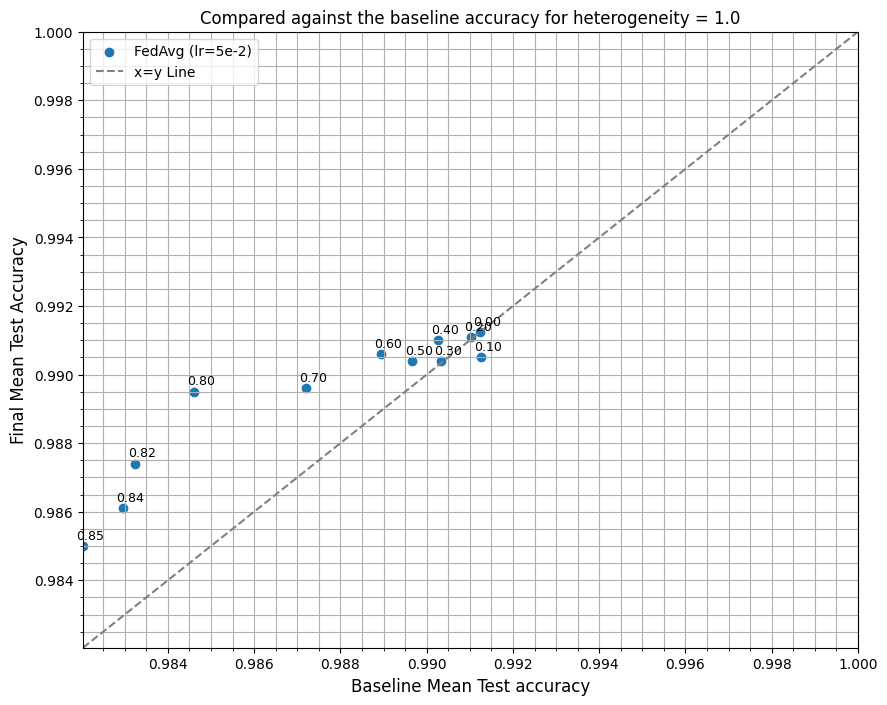

In [ ]:
tmp = modify_data(results_df)
data_type = "1.0"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

plt.figure(figsize=(10, 8))

unique_lr_values = ["5e-2"] #fed_avg['lr'].unique()
x_min= 1.0
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Corrected line extraction
    baseline_tmp = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0][[15,16,18, 20, 30, 40, 50, 60, 70, 80, 90, 100]][::-1]
    
    plt.scatter(
        baseline_tmp,
        subset['final_mean_acc'],
        marker='o', 
        label=f'FedAvg (lr={lr_value})'
    )
    
    for i in range(len(baseline_tmp)):
        plt.annotate(
            f'{subset["avail_mat"].values[i]:.2f}', 
            (baseline_tmp[i], subset['final_mean_acc'].values[i]), 
            xytext=(5, 5), 
            textcoords="offset points", 
            ha='center', 
            fontsize=9
        )
    
    # Add x=y line
    x_min = min(min(baseline_tmp), subset['final_mean_acc'].min(),x_min)


plt.plot([x_min, 1.0], [x_min, 1.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 1.0)
plt.ylim(x_min, 1.0)
plt.title(f"Compared against the baseline accuracy for heterogeneity = {data_type}")
plt.legend()
plt.show()

/tmp/ipykernel_15662/3360531088.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)


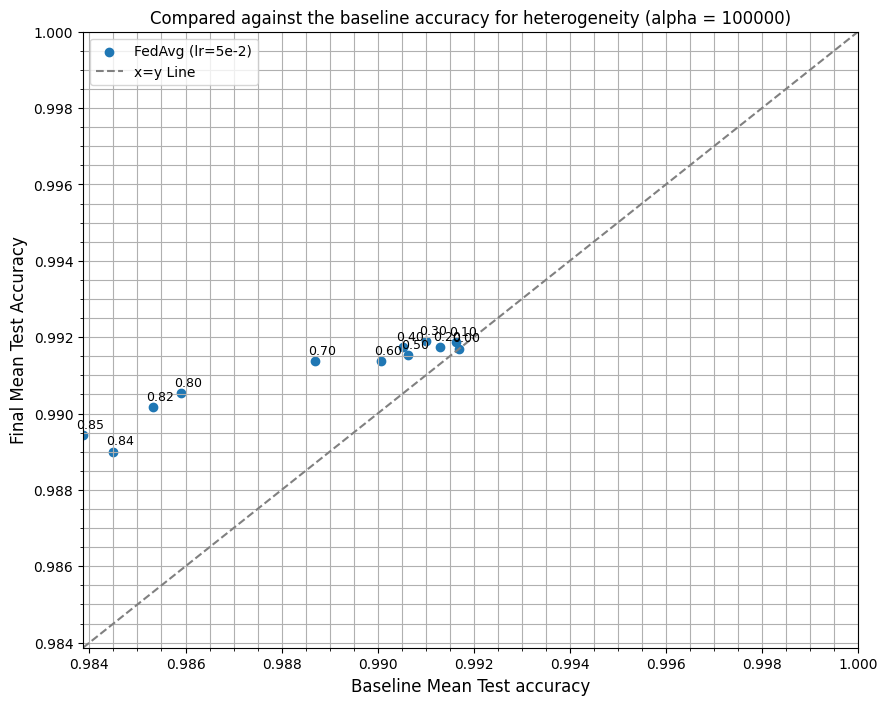

In [ ]:
tmp = modify_data(results_df)
data_type = IID
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

plt.figure(figsize=(10, 8))

unique_lr_values = ["5e-2"] #fed_avg['lr'].unique()
x_min= 1.0
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Corrected line extraction
    baseline_tmp = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0][[15,16,18, 20, 30, 40, 50, 60, 70, 80, 90, 100]][::-1]
    
    plt.scatter(
        baseline_tmp,
        subset['final_mean_acc'],
        marker='o', 
        label=f'FedAvg (lr={lr_value})'
    )
    
    for i in range(len(baseline_tmp)):
        plt.annotate(
            f'{subset["avail_mat"].values[i]:.2f}', 
            (baseline_tmp[i], subset['final_mean_acc'].values[i]), 
            xytext=(5, 5), 
            textcoords="offset points", 
            ha='center', 
            fontsize=9
        )
    
    # Add x=y line
    x_min = min(min(baseline_tmp), subset['final_mean_acc'].min(),x_min)


plt.plot([x_min, 1.0], [x_min, 1.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 1.0)
plt.ylim(x_min, 1.0)
plt.title(f"Compared against the baseline accuracy for heterogeneity (alpha = {data_type})")
plt.legend()
plt.show()

In [ ]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    seeds=["42"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF-0.0cb-10ft-mod alphaF-0.1cb-10ft2 alphaF-0.2cb-10ft2 alphaF-0.3cb-10ft2 alphaF-0.4cb-10ft2 alphaF-0.5cb-10ft2 alphaF-0.6cb-10ft2 alphaF-0.7cb-10ft2 alphaF-0.8cb-10ft2 alphaF-0.82cb-10ft2 alphaF-0.84cb-10ft2 alphaF-0.85cb-10ft2".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

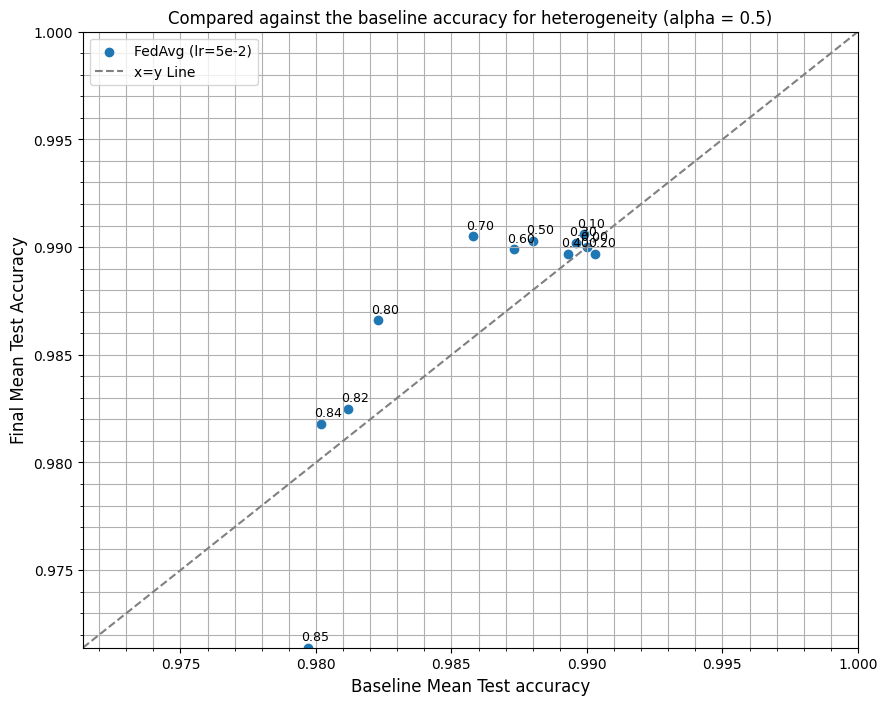

In [43]:
tmp = modify_data(results_df)
data_type = "0.5"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

plt.figure(figsize=(10, 8))

unique_lr_values = ["5e-2"] #fed_avg['lr'].unique()
x_min= 1.0
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Corrected line extraction
    baseline_tmp = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0][[15, 16, 18, 20, 30, 40, 50, 60, 70, 80, 90, 100]][::-1]
    
    plt.scatter(
        baseline_tmp,
        subset['final_mean_acc'],
        marker='o', 
        label=f'FedAvg (lr={lr_value})'
    )
    
    for i in range(len(baseline_tmp)):
        plt.annotate(
            f'{subset["avail_mat"].values[i]:.2f}', 
            (baseline_tmp[i], subset['final_mean_acc'].values[i]), 
            xytext=(5, 5), 
            textcoords="offset points", 
            ha='center', 
            fontsize=9
        )
    
    # Add x=y line
    x_min = min(min(baseline_tmp), subset['final_mean_acc'].min(),x_min)


plt.plot([x_min, 1.0], [x_min, 1.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 1.0)
plt.ylim(x_min, 1.0)
plt.title(f"Compared against the baseline accuracy for heterogeneity (alpha = {data_type})")
plt.legend()
plt.show()

In [ ]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    seeds=["42"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.5", "1.0"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF-0.0cb-10ft-mod alphaF-0.1cb-3ft2 alphaF-0.2cb-3ft2 alphaF-0.3cb-3ft2 alphaF-0.4cb-3ft2 alphaF-0.5cb-3ft2 alphaF-0.6cb-3ft2 alphaF-0.7cb-3ft2 alphaF-0.8cb-3ft2 alphaF-0.82cb-3ft2 alphaF-0.84cb-3ft2 alphaF-0.86cb-3ft2 alphaF-0.88cb-3ft2 alphaF-0.9cb-3ft2 alphaF-0.92cb-3ft2".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

In [12]:
tmp = modify_data(results_df)
data_type = "0.5"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-(\d\.\d+)cb').astype(float)

plt.figure(figsize=(10, 8))

unique_lr_values = ["5e-2"] #fed_avg['lr'].unique()
x_min= 1.0
for lr_value in unique_lr_values:
    subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
    
    # Corrected line extraction
    baseline_tmp = subset[subset['avail_mat'] == 0.0]['mean_test_acc'].values[0][[8, 10, 12, 14, 16, 18, 20, 30,40, 50, 60, 70, 80, 90, 100]][::-1]
    
    plt.scatter(
        baseline_tmp,
        subset['final_mean_acc'],
        marker='o', 
        label=f'FedAvg (lr={lr_value})'
    )
    
    for i in range(len(baseline_tmp)):
        plt.annotate(
            f'{subset["avail_mat"].values[i]:.2f}', 
            (baseline_tmp[i], subset['final_mean_acc'].values[i]), 
            xytext=(5, 5), 
            textcoords="offset points", 
            ha='center', 
            fontsize=9
        )
    
    # Add x=y line
    x_min = min(min(baseline_tmp), subset['final_mean_acc'].min(),x_min)


plt.plot([x_min, 1.0], [x_min, 1.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 1.0)
plt.ylim(x_min, 1.0)
plt.title(f"Compared against the baseline accuracy for heterogeneity (alpha = {data_type})")
plt.legend()
plt.show()

NameError: name 'results_df' is not defined

# Analysis n rounds = 50

In [75]:
import os
from datetime import datetime, timedelta

def load_data(countries=None):
    """
    Loads the CI data in df_dict a dictionary where key=country, value=dataframe of CI data.
    Returns: df_dict
    The columns of each dataframe are datetime, CI_direct, CI_LA.
    The unit of the CI data is: gCO2eq/kWh.
    """

    # prepare links to the data csv files
    folder = "../building_availability_matrices/historical_data"
    _paths = {
        "Germany": os.path.join(folder, "DE_2022_hourly.csv"),
        "Austria": os.path.join(folder, "AT_2022_hourly.csv"),
        "Ireland": os.path.join(folder, "IE_2022_hourly.csv"),
        "Great Britain": os.path.join(folder, "GB_2022_hourly.csv"),
        "France": os.path.join(folder, "FR_2022_hourly.csv"),
        "Sweden": os.path.join(folder, "SE-SE3_2022_hourly.csv"),
        "Finland": os.path.join(folder, "FI_2022_hourly.csv"),
        "Belgium": os.path.join(folder, "BE_2022_hourly.csv"),
        "Brazil": os.path.join(folder, "BR_2022_hourly.csv"),
        "Denmark": os.path.join(folder, "DK_2022_hourly.csv"),
        "Estonia": os.path.join(folder, "EE_2022_hourly.csv"),
        "Spain": os.path.join(folder, "ES_2022_hourly.csv"),
        "Hungary": os.path.join(folder, "HU_2022_hourly.csv"),
        "Singapore": os.path.join(folder, "SG_2022_hourly.csv"),
        "Japan": os.path.join(folder, "JP_2022_hourly.csv"),
        "South Africa": os.path.join(folder, "ZA_2022_hourly.csv"),
        "Peru": os.path.join(folder, "PE_2022_hourly.csv"),
        "Croatia": os.path.join(folder, "HR_2022_hourly.csv"),
    }
    # loading the data in a pandas dataframe
    df_dict = {}
    usecols = [
        "Datetime (UTC)",
        "Carbon Intensity gCO₂eq/kWh (direct)",
        "Carbon Intensity gCO₂eq/kWh (LCA)",
    ]

    for key in countries if countries else _paths.keys():
        try:
            df_dict[key] = pd.read_csv(
                _paths[key], usecols=usecols, parse_dates=["Datetime (UTC)"]
            )
            df_dict[key] = df_dict[key].rename(
                columns={
                    "Datetime (UTC)": "datetime",
                    "Carbon Intensity gCO₂eq/kWh (direct)": "CI_direct",
                    "Carbon Intensity gCO₂eq/kWh (LCA)": "CI_LCA",
                }
            )
        except KeyError:
            print(f"Data for country {key} not present")
            continue

    return df_dict

In [76]:
countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"]
n_rounds = 50
dfs = load_data(countries)

start_time = datetime(2022, 1, 1, 0, 0)


CI_matrix = pd.DataFrame(
            index=countries, columns=[i for i in range(n_rounds)]
        )
for country in countries:
    CI_values = dfs[country][
            dfs[country]["datetime"].between(start_time, start_time + timedelta(hours=n_rounds - 1))
        ]["CI_direct"].values
    CI_matrix.loc[country, :] = CI_values

In [77]:
power = 300 / 1000  # in kiloWatts
round_duration = 1  # in hours: this is duration of a FL training round
GHG_matrix = CI_matrix * power * round_duration / 1000
total_cb = GHG_matrix.sum().sum()

In [79]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_debug",
    seeds=["42", "78", "84"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2", "1e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-0.0cb-3ft alphaF50-41sl-2cb-3ft alphaF50-42sl-2cb-3ft alphaF50-43sl-2cb-3ft alphaF50-44sl-2cb-3ft alphaF50-45sl-2cb-3ft alphaF50-46sl-2cb-3ft alphaF50-47sl-2cb-3ft alphaF50-48sl-2cb-3ft alphaF50-49sl-2cb-3ft alphaF50-31sl-4cb-3ft alphaF50-32sl-4cb-3ft alphaF50-33sl-4cb-3ft alphaF50-34sl-4cb-3ft alphaF50-35sl-4cb-3ft alphaF50-36sl-4cb-3ft alphaF50-37sl-4cb-3ft alphaF50-38sl-4cb-3ft alphaF50-39sl-4cb-3ft alphaF50-40sl-4cb-3ft alphaF50-21sl-6cb-3ft alphaF50-22sl-6cb-3ft alphaF50-23sl-6cb-3ft alphaF50-24sl-6cb-3ft alphaF50-25sl-6cb-3ft alphaF50-26sl-6cb-3ft alphaF50-27sl-6cb-3ft alphaF50-28sl-6cb-3ft alphaF50-29sl-6cb-3ft alphaF50-30sl-6cb-3ft alphaF50-40sl-6cb-3ft alphaF50-11sl-8cb-3ft alphaF50-12sl-8cb-3ft alphaF50-13sl-8cb-3ft alphaF50-14sl-8cb-3ft alphaF50-15sl-8cb-3ft alphaF50-16sl-8cb-3ft alphaF50-17sl-8cb-3ft alphaF50-18sl-8cb-3ft alphaF50-19sl-8cb-3ft alphaF50-20sl-8cb-3ft alphaF50-30sl-8cb-3ft alphaF50-40sl-8cb-3ft alphaF50-10sl-9cb-3ft alphaF50-11sl-9cb-3ft alphaF50-12sl-9cb-3ft alphaF50-13sl-9cb-3ft alphaF50-14sl-9cb-3ft alphaF50-15sl-9cb-3ft alphaF50-16sl-9cb-3ft alphaF50-17sl-9cb-3ft alphaF50-18sl-9cb-3ft alphaF50-19sl-9cb-3ft alphaF50-29sl-9cb-3ft alphaF50-39sl-9cb-3ft alphaF50-6sl-10cb-3ft alphaF50-7sl-10cb-3ft alphaF50-8sl-10cb-3ft alphaF50-9sl-10cb-3ft alphaF50-10sl-10cb-3ft alphaF50-11sl-10cb-3ft alphaF50-12sl-10cb-3ft alphaF50-13sl-10cb-3ft alphaF50-14sl-10cb-3ft alphaF50-15sl-10cb-3ft alphaF50-25sl-10cb-3ft alphaF50-35sl-10cb-3ft alphaF50-45sl-10cb-3ft alphaF50-5sl-11cb-3ft alphaF50-6sl-11cb-3ft alphaF50-7sl-11cb-3ft alphaF50-8sl-11cb-3ft alphaF50-9sl-11cb-3ft alphaF50-10sl-11cb-3ft alphaF50-11sl-11cb-3ft alphaF50-12sl-11cb-3ft alphaF50-13sl-11cb-3ft alphaF50-14sl-11cb-3ft alphaF50-24sl-11cb-3ft alphaF50-34sl-11cb-3ft alphaF50-44sl-11cb-3ft alphaF50-110sl-2cb-3ft alphaF50-130sl-2cb-3ft alphaF50-150sl-2cb-3ft alphaF50-170sl-2cb-3ft alphaF50-190sl-2cb-3ft alphaF50-110sl-6cb-3ft alphaF50-130sl-6cb-3ft alphaF50-150sl-6cb-3ft alphaF50-170sl-6cb-3ft alphaF50-75sl-10cb-3ft alphaF50-95sl-10cb-3ft alphaF50-115sl-10cb-3ft alphaF50-135sl-10cb-3ft alphaF50-155sl-10cb-3ft alphaF50-74sl-11cb-3ft alphaF50-94sl-11cb-3ft alphaF50-114sl-11cb-3ft alphaF50-134sl-11cb-3ft alphaF50-154sl-11cb-3ft".split(
            " "
        )
    ),
    n_rounds="50",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

# config = ExperimentConfig(
#     base_path=os.path.join("..", "logs"),
#     experiment="mnist_debug",
#     seeds=["42", "78", "84"],
#     algorithms=["fedavg"],
#     events=["global"],
#     lr_list=["5e-2", "1e-2"],
#     alphas=["0.5"],
#     n_clients_list=["7"],
#     availabilities=list(
#         "alphaF50-0.0cb-3ft alphaF50-41sl-2cb-3ft alphaF50-42sl-2cb-3ft alphaF50-43sl-2cb-3ft alphaF50-44sl-2cb-3ft alphaF50-45sl-2cb-3ft alphaF50-46sl-2cb-3ft alphaF50-47sl-2cb-3ft alphaF50-48sl-2cb-3ft alphaF50-49sl-2cb-3ft alphaF50-31sl-4cb-3ft alphaF50-32sl-4cb-3ft alphaF50-33sl-4cb-3ft alphaF50-34sl-4cb-3ft alphaF50-35sl-4cb-3ft alphaF50-36sl-4cb-3ft alphaF50-37sl-4cb-3ft alphaF50-38sl-4cb-3ft alphaF50-39sl-4cb-3ft alphaF50-40sl-4cb-3ft alphaF50-21sl-6cb-3ft alphaF50-22sl-6cb-3ft alphaF50-23sl-6cb-3ft alphaF50-24sl-6cb-3ft alphaF50-25sl-6cb-3ft alphaF50-26sl-6cb-3ft alphaF50-27sl-6cb-3ft alphaF50-28sl-6cb-3ft alphaF50-29sl-6cb-3ft alphaF50-30sl-6cb-3ft alphaF50-40sl-6cb-3ft alphaF50-11sl-8cb-3ft alphaF50-12sl-8cb-3ft alphaF50-13sl-8cb-3ft alphaF50-14sl-8cb-3ft alphaF50-15sl-8cb-3ft alphaF50-16sl-8cb-3ft alphaF50-17sl-8cb-3ft alphaF50-18sl-8cb-3ft alphaF50-19sl-8cb-3ft alphaF50-20sl-8cb-3ft alphaF50-30sl-8cb-3ft alphaF50-40sl-8cb-3ft alphaF50-10sl-9cb-3ft alphaF50-11sl-9cb-3ft alphaF50-12sl-9cb-3ft alphaF50-13sl-9cb-3ft alphaF50-14sl-9cb-3ft alphaF50-15sl-9cb-3ft alphaF50-16sl-9cb-3ft alphaF50-17sl-9cb-3ft alphaF50-18sl-9cb-3ft alphaF50-19sl-9cb-3ft alphaF50-29sl-9cb-3ft alphaF50-39sl-9cb-3ft alphaF50-6sl-10cb-3ft alphaF50-7sl-10cb-3ft alphaF50-8sl-10cb-3ft alphaF50-9sl-10cb-3ft alphaF50-10sl-10cb-3ft alphaF50-11sl-10cb-3ft alphaF50-12sl-10cb-3ft alphaF50-13sl-10cb-3ft alphaF50-14sl-10cb-3ft alphaF50-15sl-10cb-3ft alphaF50-25sl-10cb-3ft alphaF50-35sl-10cb-3ft alphaF50-45sl-10cb-3ft alphaF50-5sl-11cb-3ft alphaF50-6sl-11cb-3ft alphaF50-7sl-11cb-3ft alphaF50-8sl-11cb-3ft alphaF50-9sl-11cb-3ft alphaF50-10sl-11cb-3ft alphaF50-11sl-11cb-3ft alphaF50-13sl-11cb-3ft alphaF50-14sl-11cb-3ft alphaF50-24sl-11cb-3ft alphaF50-44sl-11cb-3ft alphaF50-110sl-2cb-3ft alphaF50-130sl-2cb-3ft alphaF50-150sl-2cb-3ft alphaF50-170sl-2cb-3ft alphaF50-190sl-2cb-3ft alphaF50-110sl-6cb-3ft alphaF50-130sl-6cb-3ft alphaF50-150sl-6cb-3ft alphaF50-170sl-6cb-3ft alphaF50-75sl-10cb-3ft alphaF50-95sl-10cb-3ft alphaF50-115sl-10cb-3ft alphaF50-135sl-10cb-3ft alphaF50-155sl-10cb-3ft alphaF50-74sl-11cb-3ft alphaF50-94sl-11cb-3ft alphaF50-114sl-11cb-3ft alphaF50-134sl-11cb-3ft alphaF50-154sl-11cb-3ft".split(
#             " "
#         )
#     ),
#     n_rounds="50",
#     participations=["known"],
#     biased_list=["2"],
#     train_test="train",
# )


config1 = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    seeds=["42", "78", "84"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2", "1e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-2cb-3ft alphaF50-60sl-2cb-3ft alphaF50-70sl-2cb-3ft alphaF50-80sl-2cb-3ft alphaF50-90sl-2cb-3ft alphaF50-4cb-3ft alphaF50-60sl-4cb-3ft alphaF50-70sl-4cb-3ft alphaF50-80sl-4cb-3ft alphaF50-100sl-4cb-3ft alphaF50-120sl-4cb-3ft alphaF50-140sl-4cb-3ft alphaF50-160sl-4cb-3ft alphaF50-180sl-4cb-3ft alphaF50-6cb-3ft alphaF50-60sl-6cb-3ft alphaF50-70sl-6cb-3ft alphaF50-90sl-6cb-3ft alphaF50-8cb-3ft alphaF50-60sl-8cb-3ft alphaF50-80sl-8cb-3ft alphaF50-100sl-8cb-3ft alphaF50-120sl-8cb-3ft alphaF50-140sl-8cb-3ft alphaF50-160sl-8cb-3ft alphaF50-9cb-3ft alphaF50-60sl-9cb-3ft alphaF50-80sl-9cb-3ft alphaF50-100sl-9cb-3ft alphaF50-120sl-9cb-3ft alphaF50-140sl-9cb-3ft alphaF50-160sl-9cb-3ft alphaF50-55sl-10cb-3ft alphaF50-54sl-11cb-3ft".split(
            " "
        )
    ),
    n_rounds="50",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df_3ft = pd.concat([get_exp_stats(config),get_exp_stats(config1)])
# results_df_3ft = get_exp_stats(config1)

In [53]:
results_df_3ft['n'] = results_df_3ft['test_accuracy'].apply(lambda x: x.shape[0])
results_df_3ft[['availability', 'lr', 'seed','n']].sort_values(['availability','lr']).to_csv("tmp.csv", index=False)

In [80]:
# base_test_acc_3ft = results_df_3ft.loc[0, 'test_accuracy'].take([50,40,30,20,10,9,5,4])*100
carbon_budget_considered_3ft = GHG_matrix.sum().cumsum().to_numpy().take([39,29,19,9,8,4,3])
perc_cb_saved_3ft = np.insert(100*carbon_budget_considered_3ft/total_cb, 0,100.0)

In [81]:
carbon_budget_considered_3ft

array([7.980065999999999, 6.1960109999999995, 4.235079, 1.983414,
       1.773765, 0.9428550000000001, 0.7447260000000001], dtype=object)

In [82]:
tmp_3ft = modify_data(results_df_3ft)
data_type = "0.5"
fed_avg_3ft = tmp_3ft.loc[(tmp_3ft['algorithm'] == 'fedavg') & (tmp_3ft['alpha'] == data_type)]
fed_avg_3ft['slack_time'] = fed_avg_3ft['availability'].str.extract(r'-(\d+)sl')

# Extract avail_mat
fed_avg_3ft['avail_mat'] = fed_avg_3ft['availability'].str.extract(r'-(\d+)cb')
fed_avg_3ft['slack_time'] = fed_avg_3ft['slack_time'].fillna(50).astype(int)
fed_avg_3ft['avail_mat'] = fed_avg_3ft['avail_mat'].fillna(0).astype(int)

In [83]:
fed_avg_3ft.loc[fed_avg_3ft.groupby(['avail_mat','slack_time'])['final_mean_acc'].idxmax()].sort_values(['avail_mat','slack_time'])[['avail_mat', 'slack_time', 'lr', 'final_mean_acc', 'final_std_acc']].to_csv("tmp.csv")

In [115]:
_baseline = tmp_3ft.loc[tmp_3ft['availability'] == 'alphaF50-0.0cb-3ft',['lr', 'mean_test_acc', 'std_test_acc']]
for acc, std in zip(
    _baseline.loc[_baseline['lr'] == '5e-2','mean_test_acc'].values[0].take([50,40,30,20,10,9,5,4]) *100,
    _baseline.loc[_baseline['lr'] == '5e-2','std_test_acc'].values[0].take([50,40,30,20,10,9,5,4]) *100,
    ):
    print(f"\\tightcell{ {float(np.round(acc, 2))} }{ ( {float(np.round(std, 2))} ) }")
    
print("------")

for acc, std in zip(
    _baseline.loc[_baseline['lr'] == '1e-2','mean_test_acc'].values[0].take([50,40,30,20,10,9,5,4]) *100,
    _baseline.loc[_baseline['lr'] == '1e-2','std_test_acc'].values[0].take([50,40,30,20,10,9,5,4]) *100,
    ):
    print(f"\\tightcell{ {float(np.round(acc, 2))} }{ ( {float(np.round(std, 2))} ) }")
base_test_acc_3ft = _baseline.loc[_baseline['lr'] == '5e-2','mean_test_acc'].values[0].take([40,30,20,10,9,5,4]) *100

\tightcell{98.9}{0.05}
\tightcell{98.82}{0.06}
\tightcell{98.66}{0.07}
\tightcell{98.36}{0.09}
\tightcell{97.42}{0.08}
\tightcell{97.37}{0.08}
\tightcell{95.83}{0.34}
\tightcell{95.03}{0.4}
------
\tightcell{97.5}{0.2}
\tightcell{97.21}{0.18}
\tightcell{96.39}{0.17}
\tightcell{95.12}{0.45}
\tightcell{92.25}{0.49}
\tightcell{91.97}{0.54}
\tightcell{89.48}{0.98}
\tightcell{88.29}{1.22}


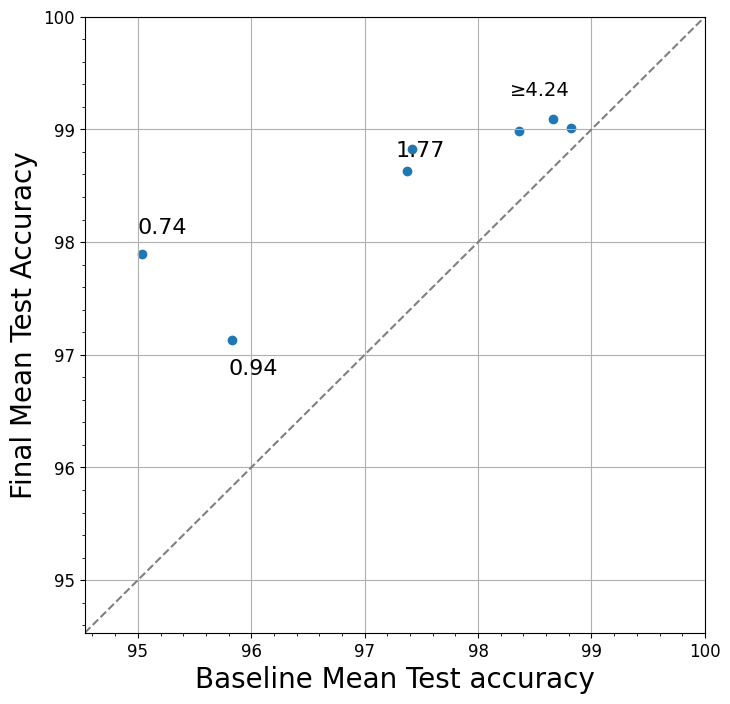

In [120]:
_tmp_3ft = fed_avg_3ft.loc[fed_avg_3ft.groupby('avail_mat')['final_mean_acc'].idxmax()]
_tmp_3ft =_tmp_3ft.loc[~_tmp_3ft['avail_mat'].isin([0])]

plt.figure(figsize=(8, 8))
plt.scatter(
    base_test_acc_3ft,
    _tmp_3ft['final_mean_acc'].values*100,
    marker='o', 
)

for i, val in enumerate(_tmp_3ft[['final_mean_acc', 'slack_time']].values):
    if i >=6:
        plt.annotate(
            # f'{100-100*perc_cb_saved[i]:.2f}_{val[1]}', 
            f'{carbon_budget_considered_3ft[i]:.2f}', 
            (base_test_acc_3ft[i],val[0]*100), 
            xytext=(15, 15), 
            textcoords="offset points", 
            ha='center', 
            fontsize=16
        )

plt.annotate(
            # f'{100-100*perc_cb_saved[i]:.2f}_{val[1]}', 
            f'{carbon_budget_considered_3ft[5]:.2f}', 
            (base_test_acc_3ft[5],_tmp_3ft[['final_mean_acc', 'slack_time']].values[5,0]*100), 
            xytext=(15, -25), 
            textcoords="offset points", 
            ha='center', 
            fontsize=16
        )

plt.annotate(
            # f'{100-100*perc_cb_saved[i]:.2f}_{val[1]}', 
            f'{carbon_budget_considered_3ft[4]:.2f}', 
            (base_test_acc_3ft[4],_tmp_3ft[['final_mean_acc', 'slack_time']].values[4,0]*100), 
            xytext=(10, 10), 
            textcoords="offset points", 
            ha='center', 
            fontsize=16
        )

plt.annotate(
            # f'{100-100*perc_cb_saved[i]:.2f}_{val[1]}', 
            f'≥{carbon_budget_considered_3ft[2]:.2f}', 
            (base_test_acc_3ft[2],_tmp_3ft[['final_mean_acc', 'slack_time']].values[2,0]*100), 
            xytext=(15, 25), 
            textcoords="offset points", 
            ha='center', 
            fontsize=14
        )
    

       
x_min = min(min(base_test_acc_3ft), min(_tmp_3ft['final_mean_acc'].values*100)) - 0.5 


plt.plot([x_min, 100.0], [x_min, 100.0], color='gray', linestyle='--')

plt.xlabel('Baseline Mean Test accuracy', fontsize=20)
plt.ylabel('Final Mean Test Accuracy', fontsize=20)
plt.grid(visible=True, which='major')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 100.0)
plt.ylim(x_min, 100.0)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
# plt.legend()
plt.tick_params(axis='both', labelsize=12)
plt.savefig("../../50_0.5_3ft_slack.png")
plt.show()

In [73]:
_tmp_3ft

,algorithm,availability,lr,alpha,test_accuracy,mean_test_acc,var_test_acc,std_test_acc,final_mean_acc,final_var_acc,final_std_acc,min_test_acc,max_test_acc,slack_time,avail_mat
1,fedavg,alphaF50-0.0cb-3ft,5e-2,0.5,"[[0.12150000035762787, 0.870199978351593, 0.91...","[0.11080000052849452, 0.8657333254814148, 0.92...","[0.0010275267318431548, 0.0004711026187559734,...","[0.032055057819993946, 0.021704898496790383, 0...",0.988967,2.288854e-07,0.000478,"[0.06729999929666519, 0.8371999859809875, 0.91...","[0.1436000019311905, 0.8898000121116638, 0.932...",50,0
205,fedavg,alphaF50-90sl-2cb-3ft,5e-2,0.5,"[[0.12150000035762787, 0.6773999929428101, 0.8...","[0.1108666683236758, 0.7030333479245504, 0.889...","[0.0010268156087435637, 0.0007205761336032246,...","[0.0320439636865286, 0.0268435491990762, 0.002...",0.990133,5.688658e-07,0.000754,"[0.0674000009894371, 0.6773999929428101, 0.887...","[0.1437000036239624, 0.7401000261306763, 0.892...",90,2
23,fedavg,alphaF50-120sl-4cb-3ft,5e-2,0.5,"[[0.12150000035762787, 0.6226999759674072, 0.8...","[0.1108666683236758, 0.6464333335558573, 0.852...","[0.0010268156087435637, 0.0002893427885821451,...","[0.0320439636865286, 0.017010079029273942, 0.0...",0.990900,2.599830e-07,0.000510,"[0.0674000009894371, 0.6226999759674072, 0.828...","[0.1437000036239624, 0.6617000102996826, 0.899...",120,4
189,fedavg,alphaF50-70sl-6cb-3ft,5e-2,0.5,"[[0.12150000035762787, 0.6330000162124634, 0.7...","[0.1108666683236758, 0.6553333401679993, 0.769...","[0.0010268156087435637, 0.0002758486990780777,...","[0.0320439636865286, 0.016608693478960882, 0.0...",0.989900,2.000664e-08,0.000141,"[0.0674000009894371, 0.6330000162124634, 0.730...","[0.1437000036239624, 0.6728000044822693, 0.812...",70,6
200,fedavg,alphaF50-8cb-3ft,5e-2,0.5,"[[0.12150000035762787, 0.3118000030517578, 0.6...","[0.11080000052849452, 0.23666666944821677, 0.6...","[0.0010275267318431548, 0.0028673356272093608,...","[0.032055057819993946, 0.05354750813258597, 0....",0.988233,2.022138e-07,0.000450,"[0.06729999929666519, 0.19089999794960022, 0.5...","[0.1436000019311905, 0.3118000030517578, 0.672...",50,8
207,fedavg,alphaF50-9cb-3ft,5e-2,0.5,"[[0.12150000035762787, 0.3118000030517578, 0.6...","[0.11080000052849452, 0.23666666944821677, 0.6...","[0.0010275267318431548, 0.0028673356272093608,...","[0.032055057819993946, 0.05354750813258597, 0....",0.986300,4.266811e-07,0.000653,"[0.06729999929666519, 0.19089999794960022, 0.5...","[0.1436000019311905, 0.3118000030517578, 0.676...",50,9
174,fedavg,alphaF50-55sl-10cb-3ft,5e-2,0.5,"[[0.12150000035762787, 0.3353999853134155, 0.4...","[0.1108666683236758, 0.25529999534289044, 0.35...","[0.0010268156087435637, 0.0032088858588823245,...","[0.0320439636865286, 0.05664702868538053, 0.04...",0.971300,2.326612e-06,0.001525,"[0.0674000009894371, 0.21410000324249268, 0.31...","[0.1437000036239624, 0.3353999853134155, 0.415...",55,10
157,fedavg,alphaF50-44sl-11cb-3ft,5e-2,0.5,"[[0.12150000035762787, 0.3208000063896179, 0.3...","[0.11080000052849452, 0.24480000138282776, 0.3...","[0.0010275267318431548, 0.0029027270788574513,...","[0.032055057819993946, 0.05387696241305231, 0....",0.978900,7.266694e-07,0.000852,"[0.06729999929666519, 0.2020999938249588, 0.29...","[0.1436000019311905, 0.3208000063896179, 0.398...",44,11


### Fine tuning step = 1

In [128]:
# For 3 steps of fine tuning
carbon_budget_considered = GHG_matrix.sum().cumsum().to_numpy().take([39,29,19,9,4,3,2])
perc_cb_saved = np.insert(100*carbon_budget_considered/total_cb, 0,100.0)

In [165]:
perc_cb_saved

array([100.0, 81.99884401082006, 63.66685933153, 43.51738222396906,
       20.380489985280406, 9.688268251142505, 7.652401760186194,
       5.728928243898306], dtype=object)

In [129]:
carbon_budget_considered

array([7.980065999999999, 6.1960109999999995, 4.235079, 1.983414,
       0.9428550000000001, 0.7447260000000001, 0.5575350000000001],
      dtype=object)

In [130]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_debug",
    seeds=["42", "78", "84"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2", "1e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-0.0cb-3ft alphaF50-41sl-2cb-1ft alphaF50-42sl-2cb-1ft alphaF50-43sl-2cb-1ft alphaF50-44sl-2cb-1ft alphaF50-45sl-2cb-1ft alphaF50-46sl-2cb-1ft alphaF50-47sl-2cb-1ft alphaF50-48sl-2cb-1ft alphaF50-49sl-2cb-1ft alphaF50-31sl-4cb-1ft alphaF50-32sl-4cb-1ft alphaF50-33sl-4cb-1ft alphaF50-34sl-4cb-1ft alphaF50-35sl-4cb-1ft alphaF50-36sl-4cb-1ft alphaF50-37sl-4cb-1ft alphaF50-38sl-4cb-1ft alphaF50-39sl-4cb-1ft alphaF50-40sl-4cb-1ft alphaF50-21sl-6cb-1ft alphaF50-22sl-6cb-1ft alphaF50-23sl-6cb-1ft alphaF50-24sl-6cb-1ft alphaF50-25sl-6cb-1ft alphaF50-26sl-6cb-1ft alphaF50-27sl-6cb-1ft alphaF50-28sl-6cb-1ft alphaF50-29sl-6cb-1ft alphaF50-30sl-6cb-1ft alphaF50-40sl-6cb-1ft alphaF50-11sl-8cb-1ft alphaF50-12sl-8cb-1ft alphaF50-13sl-8cb-1ft alphaF50-14sl-8cb-1ft alphaF50-15sl-8cb-1ft alphaF50-16sl-8cb-1ft alphaF50-17sl-8cb-1ft alphaF50-18sl-8cb-1ft alphaF50-19sl-8cb-1ft alphaF50-20sl-8cb-1ft alphaF50-30sl-8cb-1ft alphaF50-40sl-8cb-1ft alphaF50-6sl-9cb-1ft alphaF50-7sl-9cb-1ft alphaF50-8sl-9cb-1ft alphaF50-9sl-9cb-1ft alphaF50-10sl-9cb-1ft alphaF50-11sl-9cb-1ft alphaF50-12sl-9cb-1ft alphaF50-13sl-9cb-1ft alphaF50-14sl-9cb-1ft alphaF50-15sl-9cb-1ft alphaF50-25sl-9cb-1ft alphaF50-35sl-9cb-1ft alphaF50-45sl-9cb-1ft alphaF50-5sl-10cb-1ft alphaF50-6sl-10cb-1ft alphaF50-7sl-10cb-1ft alphaF50-8sl-10cb-1ft alphaF50-9sl-10cb-1ft alphaF50-10sl-10cb-1ft alphaF50-11sl-10cb-1ft alphaF50-12sl-10cb-1ft alphaF50-13sl-10cb-1ft alphaF50-14sl-10cb-1ft alphaF50-24sl-10cb-1ft alphaF50-34sl-10cb-1ft alphaF50-44sl-10cb-1ft alphaF50-4sl-11cb-1ft alphaF50-5sl-11cb-1ft alphaF50-6sl-11cb-1ft alphaF50-7sl-11cb-1ft alphaF50-8sl-11cb-1ft alphaF50-9sl-11cb-1ft alphaF50-10sl-11cb-1ft alphaF50-11sl-11cb-1ft alphaF50-12sl-11cb-1ft alphaF50-13sl-11cb-1ft alphaF50-23sl-11cb-1ft alphaF50-33sl-11cb-1ft alphaF50-43sl-11cb-1ft alphaF50-3sl-12cb-1ft alphaF50-4sl-12cb-1ft alphaF50-5sl-12cb-1ft alphaF50-6sl-12cb-1ft alphaF50-7sl-12cb-1ft alphaF50-8sl-12cb-1ft alphaF50-9sl-12cb-1ft alphaF50-10sl-12cb-1ft alphaF50-11sl-12cb-1ft alphaF50-12sl-12cb-1ft alphaF50-22sl-12cb-1ft alphaF50-32sl-12cb-1ft alphaF50-42sl-12cb-1ft alphaF50-110sl-2cb-1ft alphaF50-130sl-2cb-1ft alphaF50-150sl-2cb-1ft alphaF50-170sl-2cb-1ft alphaF50-190sl-2cb-1ft alphaF50-110sl-6cb-1ft alphaF50-130sl-6cb-1ft alphaF50-150sl-6cb-1ft alphaF50-170sl-6cb-1ft alphaF50-75sl-9cb-1ft alphaF50-95sl-9cb-1ft alphaF50-115sl-9cb-1ft alphaF50-135sl-9cb-1ft alphaF50-155sl-9cb-1ft alphaF50-74sl-10cb-1ft alphaF50-94sl-10cb-1ft alphaF50-114sl-10cb-1ft alphaF50-134sl-10cb-1ft alphaF50-154sl-10cb-1ft alphaF50-73sl-11cb-1ft alphaF50-93sl-11cb-1ft alphaF50-113sl-11cb-1ft alphaF50-133sl-11cb-1ft alphaF50-153sl-11cb-1ft alphaF50-72sl-12cb-1ft alphaF50-92sl-12cb-1ft alphaF50-112sl-12cb-1ft alphaF50-132sl-12cb-1ft alphaF50-152sl-12cb-1ft".split(
            " "
        )
    ),
    n_rounds="50",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

config1 = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    seeds=["42", "78", "84"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2", "1e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-2cb-1ft alphaF50-60sl-2cb-1ft alphaF50-70sl-2cb-1ft alphaF50-80sl-2cb-1ft alphaF50-90sl-2cb-1ft alphaF50-4cb-1ft alphaF50-60sl-4cb-1ft alphaF50-70sl-4cb-1ft alphaF50-80sl-4cb-1ft alphaF50-100sl-4cb-1ft alphaF50-120sl-4cb-1ft alphaF50-140sl-4cb-1ft alphaF50-160sl-4cb-1ft alphaF50-180sl-4cb-1ft alphaF50-6cb-1ft alphaF50-60sl-6cb-1ft alphaF50-70sl-6cb-1ft alphaF50-90sl-6cb-1ft alphaF50-8cb-1ft alphaF50-60sl-8cb-1ft alphaF50-80sl-8cb-1ft alphaF50-100sl-8cb-1ft alphaF50-120sl-8cb-1ft alphaF50-140sl-8cb-1ft alphaF50-160sl-8cb-1ft alphaF50-55sl-9cb-1ft alphaF50-54sl-10cb-1ft alphaF50-53sl-11cb-1ft alphaF50-52sl-12cb-1ft".split(
            " "
        )
    ),
    n_rounds="50",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = pd.concat([get_exp_stats(config),get_exp_stats(config1)])

In [131]:
results_df['n'] = results_df['test_accuracy'].apply(lambda x: x.shape[0])
results_df[['availability', 'lr', 'seed','n']].sort_values(['availability','lr']).reset_index(drop=True).to_csv("tmp.csv")

In [132]:
tmp = modify_data(results_df)
data_type = "0.5"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['slack_time'] = fed_avg['availability'].str.extract(r'-(\d+)sl')

# Extract avail_mat
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'-(\d+)cb')
fed_avg['slack_time'] = fed_avg['slack_time'].fillna(50).astype(int)
fed_avg['avail_mat'] = fed_avg['avail_mat'].fillna(0).astype(int)

# removing last point
fed_avg = fed_avg.loc[~fed_avg['avail_mat'].isin([12])]

In [133]:
_baseline = tmp.loc[tmp['availability'] == 'alphaF50-0.0cb-3ft',['lr', 'mean_test_acc', 'std_test_acc']]
for acc, std in zip(
    _baseline.loc[_baseline['lr'] == '5e-2','mean_test_acc'].values[0].take([50,40,30,20,10,5,4,3]) *100,
    _baseline.loc[_baseline['lr'] == '5e-2','std_test_acc'].values[0].take([50,40,30,20,10,5,4,3]) *100,
    ):
    print(f"\\tightcell{ {float(np.round(acc, 2))} }{ ( {float(np.round(std, 2))} ) }")
    
print("------")

for acc, std in zip(
    _baseline.loc[_baseline['lr'] == '1e-2','mean_test_acc'].values[0].take([50,40,30,20,10,5,4,3]) *100,
    _baseline.loc[_baseline['lr'] == '1e-2','std_test_acc'].values[0].take([50,40,30,20,10,5,4,3]) *100,
    ):
    print(f"\\tightcell{ {float(np.round(acc, 2))} }{ ( {float(np.round(std, 2))} ) }")
base_test_acc = _baseline.loc[_baseline['lr'] == '5e-2','mean_test_acc'].values[0].take([40,30,20,10,5,4,3]) *100

\tightcell{98.9}{0.05}
\tightcell{98.82}{0.06}
\tightcell{98.66}{0.07}
\tightcell{98.36}{0.09}
\tightcell{97.42}{0.08}
\tightcell{95.83}{0.34}
\tightcell{95.03}{0.4}
\tightcell{93.9}{0.33}
------
\tightcell{97.5}{0.2}
\tightcell{97.21}{0.18}
\tightcell{96.39}{0.17}
\tightcell{95.12}{0.45}
\tightcell{92.25}{0.49}
\tightcell{89.48}{0.98}
\tightcell{88.29}{1.22}
\tightcell{85.9}{0.26}


In [134]:
fed_avg.loc[fed_avg.groupby(['avail_mat','slack_time'])['final_mean_acc'].idxmax()].sort_values(['avail_mat','slack_time'])[['avail_mat', 'slack_time', 'lr', 'final_mean_acc', 'final_std_acc']].to_csv("tmp.csv")

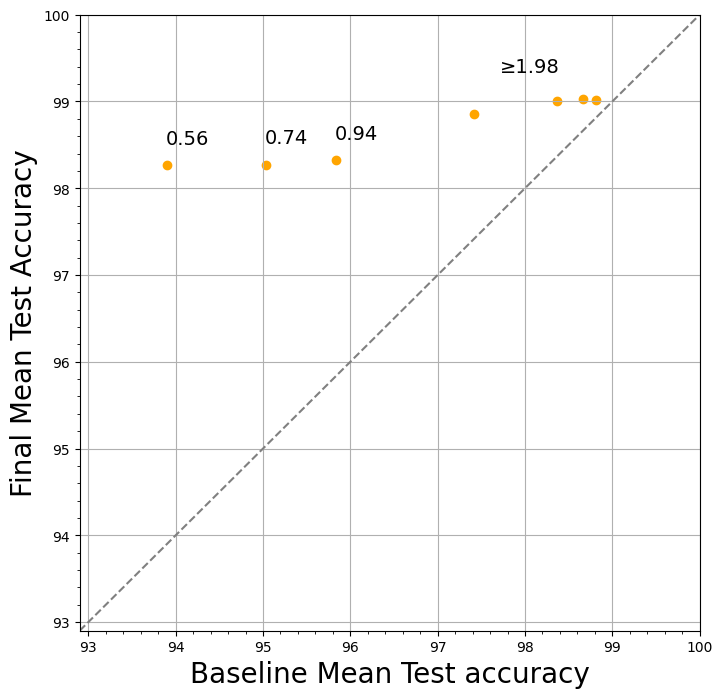

In [135]:
_tmp = fed_avg.loc[fed_avg.groupby('avail_mat')['final_mean_acc'].idxmax()]
_tmp = _tmp.loc[~_tmp['avail_mat'].isin([0])]


plt.figure(figsize=(8,8))
plt.scatter(
    base_test_acc,
    _tmp['final_mean_acc'].values*100,
    marker='o', 
    color='orange'
)

for i, val in enumerate(_tmp[['final_mean_acc', 'slack_time']].values):
    if i>= 4:
        plt.annotate(
            # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
            f'{carbon_budget_considered[i]:.2f}', 
            (base_test_acc[i],val[0]*100), 
            xytext=(15, 15), 
            textcoords="offset points", 
            ha='center', 
            fontsize=14
        )
    

plt.annotate(
            # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
            f'≥{carbon_budget_considered[3]:.2f}', 
            (base_test_acc[3],_tmp[['final_mean_acc', 'slack_time']].values[3,0]*100), 
            xytext=(40, 30), 
            textcoords="offset points", 
            ha='center', 
            fontsize=14
        )
    
       


x_min = min(min(base_test_acc), min(_tmp['final_mean_acc'].values*100))


plt.plot([x_min-1, 100.0], [x_min-1, 100.0], color='gray', linestyle='--')

plt.xlabel('Baseline Mean Test accuracy', fontsize=20)
plt.ylabel('Final Mean Test Accuracy', fontsize=20)
plt.grid(visible=True, which='major')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min-1, 100.0)
plt.ylim(x_min-1, 100.0)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
plt.savefig("../../50_0.5_1ft_slack.png")
plt.show()

In [136]:
_tmp

,algorithm,availability,lr,alpha,test_accuracy,mean_test_acc,var_test_acc,std_test_acc,final_mean_acc,final_var_acc,final_std_acc,min_test_acc,max_test_acc,slack_time,avail_mat
73,fedavg,alphaF50-150sl-2cb-1ft,5e-2,0.5,"[[0.12150000035762787, 0.7085000276565552, 0.6...","[0.1108666683236758, 0.745033343633016, 0.6320...","[0.0010268156087435637, 0.002743103127806358, ...","[0.0320439636865286, 0.052374642030340965, 0.0...",0.990167,6.889718e-08,0.000262,"[0.0674000009894371, 0.7074999809265137, 0.608...","[0.1437000036239624, 0.819100022315979, 0.6524...",150,2
2,fedavg,alphaF50-100sl-4cb-1ft,5e-2,0.5,"[[0.12150000035762787, 0.6331999897956848, 0.7...","[0.1108666683236758, 0.6571000019709269, 0.803...","[0.0010268156087435637, 0.0002856069562216451,...","[0.0320439636865286, 0.016899909947146022, 0.0...",0.990333,2.222960e-09,0.000047,"[0.0674000009894371, 0.6331999897956848, 0.776...","[0.1437000036239624, 0.6690999865531921, 0.842...",100,4
228,fedavg,alphaF50-70sl-6cb-1ft,5e-2,0.5,"[[0.12150000035762787, 0.6335999965667725, 0.7...","[0.1108666683236758, 0.6567666530609131, 0.801...","[0.0010268156087435637, 0.00027142865076494144...","[0.0320439636865286, 0.016475091828725613, 0.0...",0.990067,1.555542e-08,0.000125,"[0.0674000009894371, 0.6335999965667725, 0.773...","[0.1437000036239624, 0.6704999804496765, 0.840...",70,6
248,fedavg,alphaF50-8cb-1ft,5e-2,0.5,"[[0.12150000035762787, 0.41119998693466187, 0....","[0.11080000052849452, 0.41049999992052716, 0.7...","[0.0010275267318431548, 0.008325618765319318, ...","[0.032055057819993946, 0.09124482870453163, 0....",0.988600,4.266811e-07,0.000653,"[0.06729999929666519, 0.29840001463890076, 0.6...","[0.1436000019311905, 0.5218999981880188, 0.764...",50,8
206,fedavg,alphaF50-55sl-9cb-1ft,5e-2,0.5,"[[0.12150000035762787, 0.321399986743927, 0.66...","[0.1108666683236758, 0.2450666626294454, 0.612...","[0.0010268156087435637, 0.002925714842007999, ...","[0.0320439636865286, 0.05408987744493418, 0.04...",0.983300,4.266493e-07,0.000653,"[0.0674000009894371, 0.20260000228881836, 0.54...","[0.1437000036239624, 0.321399986743927, 0.6660...",55,9
205,fedavg,alphaF50-54sl-10cb-1ft,5e-2,0.5,"[[0.12150000035762787, 0.3352999985218048, 0.4...","[0.1108666683236758, 0.2550666679938634, 0.358...","[0.0010268156087435637, 0.0032195753374703903,...","[0.0320439636865286, 0.056741301866192584, 0.0...",0.982733,6.221903e-08,0.000249,"[0.0674000009894371, 0.21379999816417694, 0.31...","[0.1437000036239624, 0.3352999985218048, 0.415...",54,10
232,fedavg,alphaF50-73sl-11cb-1ft,5e-2,0.5,"[[0.12150000035762787, 0.3732999861240387, 0.5...","[0.11080000052849452, 0.3008666584889094, 0.45...","[0.0010275267318431548, 0.003114708391136083, ...","[0.032055057819993946, 0.05580957257618162, 0....",0.982633,2.722198e-06,0.001650,"[0.06729999929666519, 0.23749999701976776, 0.3...","[0.1436000019311905, 0.3732999861240387, 0.520...",73,11


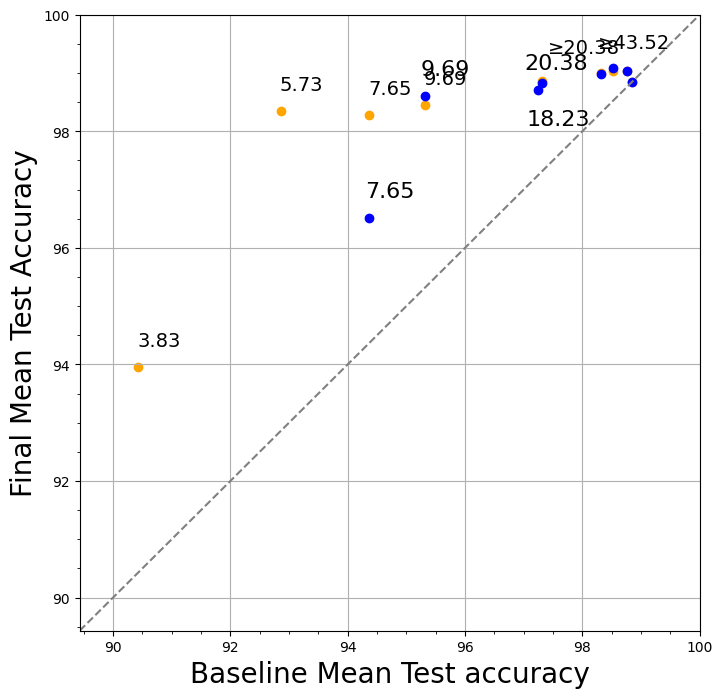

In [ ]:
_tmp = fed_avg.loc[fed_avg.groupby('avail_mat')['final_mean_acc'].idxmax()]


plt.figure(figsize=(8,8))
plt.scatter(
    base_test_acc,
    _tmp['final_mean_acc'].values*100,
    s=120,
    marker='o',
    color='orange',
    alpha=0.8,
    label='1 fine tuning step'
)

for i, val in enumerate(_tmp[['final_mean_acc', 'slack_time']].values):
    if i>= 5:
        plt.annotate(
            # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
            f'{perc_cb_saved[i]:.2f}', 
            (base_test_acc[i],val[0]*100), 
            xytext=(15, 15), 
            textcoords="offset points", 
            ha='center', 
            fontsize=14
        )
    

plt.annotate(
            # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
            f'≥{perc_cb_saved[4]:.2f}', 
            (base_test_acc[4],_tmp[['final_mean_acc', 'slack_time']].values[4,0]*100), 
            xytext=(30, 20), 
            textcoords="offset points", 
            ha='center', 
            fontsize=14
        )
    

_tmp_3ft = fed_avg_3ft.loc[fed_avg_3ft.groupby('avail_mat')['final_mean_acc'].idxmax()]

plt.scatter(
    base_test_acc_3ft,
    _tmp_3ft['final_mean_acc'].values*100,
    marker='o', 
    color='b'
)

for i, val in enumerate(_tmp_3ft[['final_mean_acc', 'slack_time']].values):
    if i >=6:
        plt.annotate(
            # f'{100-100*perc_cb_saved[i]:.2f}_{val[1]}', 
            f'{perc_cb_saved_3ft[i]:.2f}', 
            (base_test_acc_3ft[i],val[0]*100), 
            xytext=(15, 15), 
            textcoords="offset points", 
            ha='center', 
            fontsize=16
        )

plt.annotate(
            # f'{100-100*perc_cb_saved[i]:.2f}_{val[1]}', 
            f'{perc_cb_saved_3ft[5]:.2f}', 
            (base_test_acc_3ft[5],_tmp_3ft[['final_mean_acc', 'slack_time']].values[5,0]*100), 
            xytext=(15, -25), 
            textcoords="offset points", 
            ha='center', 
            fontsize=16
        )

plt.annotate(
            # f'{100-100*perc_cb_saved[i]:.2f}_{val[1]}', 
            f'{perc_cb_saved_3ft[4]:.2f}', 
            (base_test_acc_3ft[4],_tmp_3ft[['final_mean_acc', 'slack_time']].values[4,0]*100), 
            xytext=(10, 10), 
            textcoords="offset points", 
            ha='center', 
            fontsize=16
        )

plt.annotate(
            # f'{100-100*perc_cb_saved[i]:.2f}_{val[1]}', 
            f'≥{perc_cb_saved_3ft[3]:.2f}', 
            (base_test_acc_3ft[2],_tmp_3ft[['final_mean_acc', 'slack_time']].values[4,0]*100), 
            xytext=(15, 25), 
            textcoords="offset points", 
            ha='center', 
            fontsize=20
        )
    

       
x_min = min(min(base_test_acc_3ft), min(_tmp_3ft['final_mean_acc'].values*100),  min(base_test_acc), min(_tmp['final_mean_acc'].values*100)) - 0.5 


plt.plot([x_min-0.5, 100.0], [x_min-0.5, 100.0], color='gray', linestyle='--')

plt.xlabel('Baseline Mean Test accuracy', fontsize=20)
plt.ylabel('Final Mean Test Accuracy', fontsize=20)
plt.grid(visible=True, which='major')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min-0.5, 100.0)
plt.ylim(x_min-0.5, 100.0)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
plt.savefig("../../50_0.5_1ft_slack.png")
plt.show()

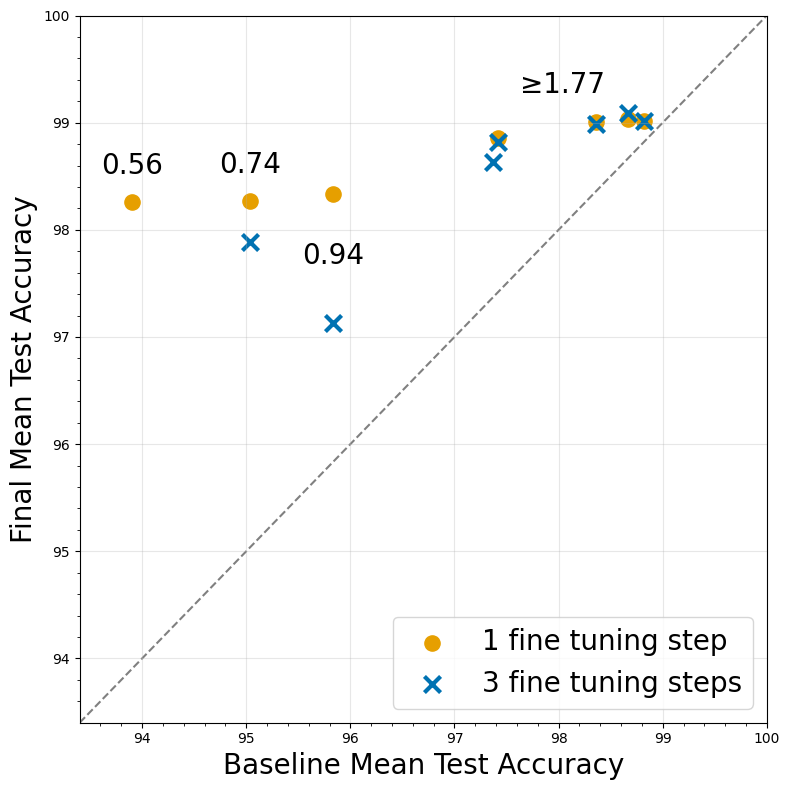

In [164]:
plt.figure(figsize=(8, 8))

# Plot for original method (orange)
plt.scatter(
    base_test_acc,
    _tmp['final_mean_acc'].values * 100,
    s=120,
    marker='o',
    color='#E69F00',
    # alpha=0.8,
    label='1 fine tuning step'
)

# Annotations for orange points (avoid duplicates)
used_labels = set()

if f'{carbon_budget_considered[6]:.2f}' not in used_labels:
    plt.annotate(
    f'{carbon_budget_considered[6]:.2f}',
    (base_test_acc[6], _tmp['final_mean_acc'].values[6] * 100),
    xytext=(0, 20),
    textcoords="offset points",
    ha='center',
    fontsize=20
)
used_labels.add(f'{carbon_budget_considered[6]:.2f}')

if f'{carbon_budget_considered[5]:.2f}' not in used_labels:
    plt.annotate(
    f'{carbon_budget_considered[5]:.2f}',
    (base_test_acc[5], _tmp['final_mean_acc'].values[5] * 100),
    xytext=(0, 20),
    textcoords="offset points",
    ha='center',
    fontsize=20
)
used_labels.add(f'{carbon_budget_considered[5]:.2f}')

if f'{carbon_budget_considered[4]:.2f}' not in used_labels:
    plt.annotate(
    f'{carbon_budget_considered[4]:.2f}',
    (base_test_acc[4], _tmp['final_mean_acc'].values[4] * 100),
    xytext=(0, -50),
    textcoords="offset points",
    ha='center',
    fontsize=20
)
used_labels.add(f'{carbon_budget_considered[4]:.2f}')


# Special annotation (≥ value)
# plt.annotate(
#     f'≥{perc_cb_saved[4]:.2f}',
#     (base_test_acc[4], _tmp['final_mean_acc'].values[4] * 100),
#     xytext=(30, 20),
#     textcoords="offset points",
#     ha='center',
#     fontsize=14
# )

# Plot for 3ft method (blue)
plt.scatter(
    base_test_acc_3ft,
    _tmp_3ft['final_mean_acc'].values * 100,
    s=135,
    marker='x',
    color='#0072B2',
    linewidths=3,
    label='3 fine tuning steps'
)

# Annotations for blue points
for i, (acc, slack) in enumerate(_tmp_3ft[['final_mean_acc', 'slack_time']].values):
    label = f'{carbon_budget_considered_3ft[i]:.2f}'
    if label not in used_labels and i >= 5:
        plt.annotate(
            label,
            (base_test_acc_3ft[i], acc * 100),
            xytext=(0, 45),
            textcoords="offset points",
            ha='center',
            fontsize=20
        )

# Specific useful annotations
# plt.annotate(f'{perc_cb_saved_3ft[5]:.2f}',
#              (base_test_acc_3ft[5], _tmp_3ft['final_mean_acc'].values[5] * 100),
#              xytext=(15, -25), textcoords="offset points", ha='center', fontsize=14)

# plt.annotate(f'{perc_cb_saved_3ft[4]:.2f}',
#              (base_test_acc_3ft[4], _tmp_3ft['final_mean_acc'].values[4] * 100),
#              xytext=(10, 10), textcoords="offset points", ha='center', fontsize=14)

plt.annotate(f'≥{carbon_budget_considered_3ft[4]:.2f}',
             (base_test_acc_3ft[4], _tmp_3ft['final_mean_acc'].values[4] * 100),
             xytext=(50, 50), textcoords="offset points", ha='center', fontsize=20)

# Diagonal reference line
x_min = min(base_test_acc.min(), base_test_acc_3ft.min(), 
            _tmp['final_mean_acc'].min()*100, _tmp_3ft['final_mean_acc'].min()*100) - 0.5

plt.plot([x_min, 100], [x_min, 100], color='gray', linestyle='--', zorder=1)

# Axes labels and aesthetics
plt.xlabel('Baseline Mean Test Accuracy', fontsize=20)
plt.ylabel('Final Mean Test Accuracy', fontsize=20)
plt.grid(visible=True, which='major', alpha=0.3)
plt.minorticks_on()
plt.xlim(x_min, 100.0)
plt.ylim(x_min, 100.0)

# Optional legend
plt.legend(fontsize=20,loc=4)

plt.tight_layout()
plt.savefig("../../50_0.5_final.png")
plt.show()
